In [1]:
import sys
!{sys.executable} -m pip install pycwt


In [2]:
import xarray as xr
import numpy as np
import datetime
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from netCDF4 import Dataset
import datetime
import pandas as pd
from scipy.fft import fft, fftfreq
import matplotlib.dates as mdates
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
from scipy.fft import fft, fftfreq
from scipy.signal import periodogram, welch, detrend
import pywt
from __future__ import division
import matplotlib.colors as mcolors
import pycwt as wavelet
from pycwt.helpers import find

In [3]:
file1 = "/media/hp/TOSHIBA EXT/sci_xrsf-l2-flx1s_g18_d20260201_v2-2-1.nc"
file2 = "/media/hp/TOSHIBA EXT/sci_xrsf-l2-flx1s_g18_d20260202_v2-2-1.nc"

ds1 = xr.open_dataset(file1)
ds2 = xr.open_dataset(file2)

In [4]:
ds1

<xarray.Dataset> Size: 9MB
Dimensions:                  (time: 86400, quad_diode: 4)
Coordinates:
  * time                     (time) datetime64[ns] 691kB 2026-01-31T23:59:59....
Dimensions without coordinates: quad_diode
Data variables: (12/19)
    xrsa_flux                (time) float32 346kB ...
    xrsb_flux                (time) float32 346kB ...
    xrsa1_flux               (time) float32 346kB ...
    xrsa2_flux               (time) float32 346kB ...
    xrsb1_flux               (time) float32 346kB ...
    xrsb2_flux               (time) float32 346kB ...
    ...                       ...
    xrsb2_flags              (time) float32 346kB ...
    corrected_current_xrsa2  (time, quad_diode) float32 1MB ...
    corrected_current_xrsb2  (time, quad_diode) float32 1MB ...
    au_factor                (time) float32 346kB ...
    roll_angle               (time) float32 346kB ...
    yaw_flip_flag            (time) float32 346kB ...
Attributes: (12/48)
    Conventions:                   ACDD-1.3, Spase v2.2.6
    title:                         L2 XRS 1-s fluxes
    summary:                       The X-Ray 1s flux product consists of high...
    keywords:                      NumericalData.MeasurementType.Irradiance
    keywords_vocabulary:           SPASE: Space Physics Archive Search and Ex...
    naming_authority:              gov.nesdis.noaa
    ...                            ...
    input_system_environments:     sci
    input_files_first:             sci_exis-l1b-sfxr_g18_d20260131_v0-0-2.nc
    input_files_last:              sci_exis-l1b-sfxr_g18_d20260202_v0-0-2.nc
    input_files_total:             3
    git_commit_hash:               61741bab5c1d390738ae50a0c36781d22535d401
    git_commit_date:               2026-01-15T21:52:02

In [5]:
ds2

<xarray.Dataset> Size: 9MB
Dimensions:                  (time: 86400, quad_diode: 4)
Coordinates:
  * time                     (time) datetime64[ns] 691kB 2026-02-01T23:59:59....
Dimensions without coordinates: quad_diode
Data variables: (12/19)
    xrsa_flux                (time) float32 346kB ...
    xrsb_flux                (time) float32 346kB ...
    xrsa1_flux               (time) float32 346kB ...
    xrsa2_flux               (time) float32 346kB ...
    xrsb1_flux               (time) float32 346kB ...
    xrsb2_flux               (time) float32 346kB ...
    ...                       ...
    xrsb2_flags              (time) float32 346kB ...
    corrected_current_xrsa2  (time, quad_diode) float32 1MB ...
    corrected_current_xrsb2  (time, quad_diode) float32 1MB ...
    au_factor                (time) float32 346kB ...
    roll_angle               (time) float32 346kB ...
    yaw_flip_flag            (time) float32 346kB ...
Attributes: (12/48)
    Conventions:                   ACDD-1.3, Spase v2.2.6
    title:                         L2 XRS 1-s fluxes
    summary:                       The X-Ray 1s flux product consists of high...
    keywords:                      NumericalData.MeasurementType.Irradiance
    keywords_vocabulary:           SPASE: Space Physics Archive Search and Ex...
    naming_authority:              gov.nesdis.noaa
    ...                            ...
    input_system_environments:     sci
    input_files_first:             sci_exis-l1b-sfxr_g18_d20260201_v0-0-2.nc
    input_files_last:              sci_exis-l1b-sfxr_g18_d20260203_v0-0-2.nc
    input_files_total:             3
    git_commit_hash:               61741bab5c1d390738ae50a0c36781d22535d401
    git_commit_date:               2026-01-15T21:52:02

In [6]:
ds = xr.concat([ds1, ds2], dim="time")

In [7]:
time = ds["time"].values
xrsa = ds["xrsa_flux"].values
xrsb = ds["xrsb_flux"].values

In [8]:
time = pd.to_datetime(ds['time'].values)

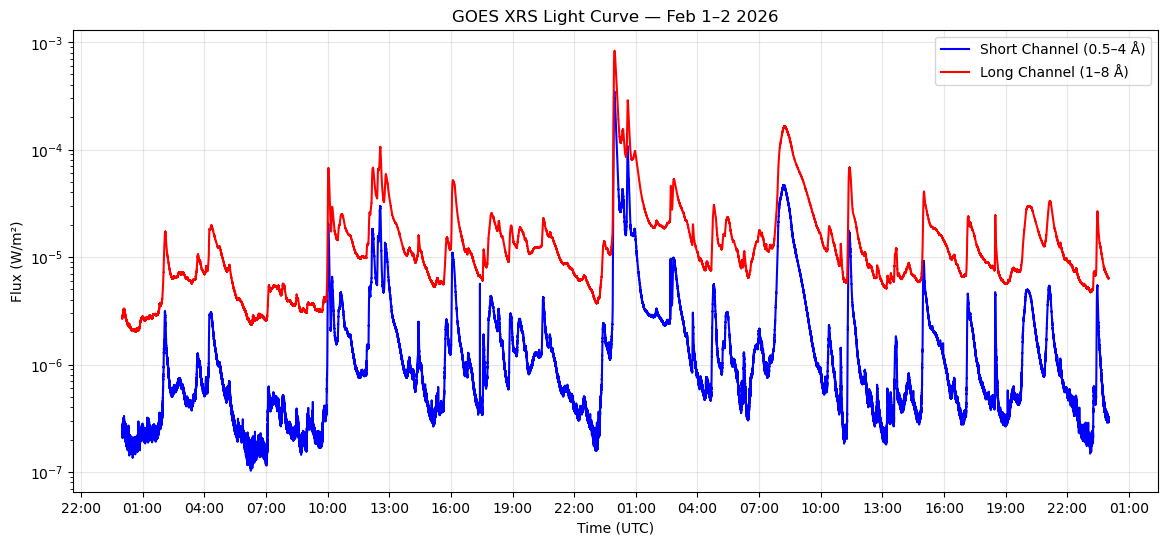

In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(14,6))

plt.plot(time, xrsa, color='blue', label='Short Channel (0.5–4 Å)')
plt.plot(time, xrsb, color='red', label='Long Channel (1–8 Å)')

plt.yscale("log")

plt.xlabel("Time (UTC)")
plt.ylabel("Flux (W/m²)")
plt.title("GOES XRS Light Curve — Feb 1–2 2026")

plt.legend()

ax = plt.gca()

ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.grid(alpha=0.3)

plt.show()

In [10]:
import pandas as pd

M1_start = pd.Timestamp("2026-02-01 11:15")
M1_end   = pd.Timestamp("2026-02-01 11:30")

M2_start = pd.Timestamp("2026-02-01 11:52")
M2_end   = pd.Timestamp("2026-02-01 12:20")

X_start  = pd.Timestamp("2026-02-01 23:44")
X_end    = pd.Timestamp("2026-02-02 00:04")

In [11]:
mask_M1 = (time >= M1_start) & (time <= M1_end)
mask_M2 = (time >= M2_start) & (time <= M2_end)
mask_X  = (time >= X_start)  & (time <= X_end)

time_M1 = time[mask_M1]
flux_M1 = xrsb[mask_M1]

time_M2 = time[mask_M2]
flux_M2 = xrsb[mask_M2]

time_X  = time[mask_X]
flux_X  = xrsb[mask_X]

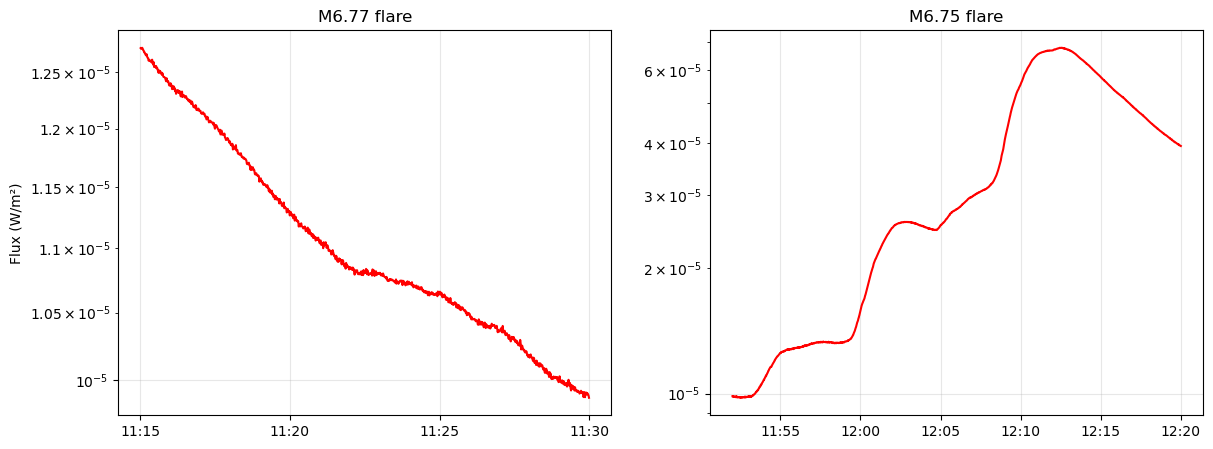

In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(1,2, figsize=(14,5))

ax[0].plot(time_M1, flux_M1, color='red')
ax[0].set_title("M6.77 flare")
ax[0].set_yscale("log")
ax[0].set_ylabel("Flux (W/m²)")

ax[1].plot(time_M2, flux_M2, color='red')
ax[1].set_title("M6.75 flare")
ax[1].set_yscale("log")

for a in ax:
    a.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    a.grid(alpha=0.3)

plt.show()

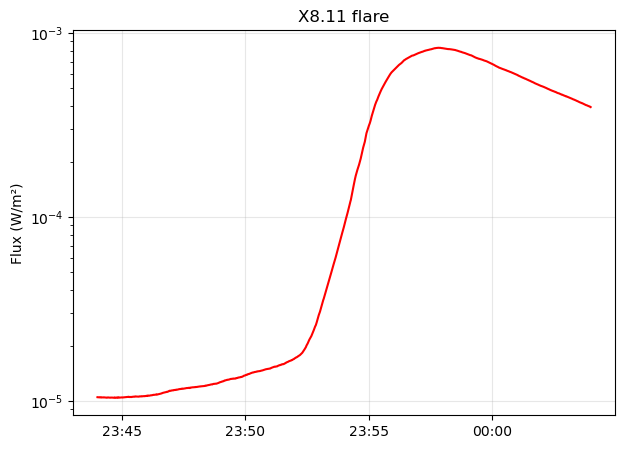

In [13]:
plt.figure(figsize=(7,5))

plt.plot(time_X, flux_X, color='red')

plt.yscale("log")

plt.title("X8.11 flare")
plt.ylabel("Flux (W/m²)")

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.grid(alpha=0.3)

plt.show()

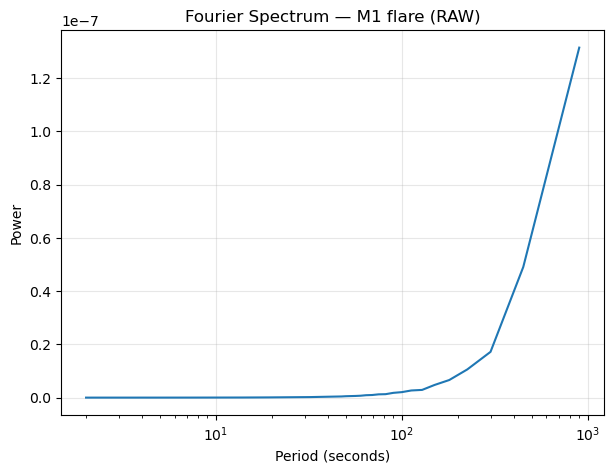

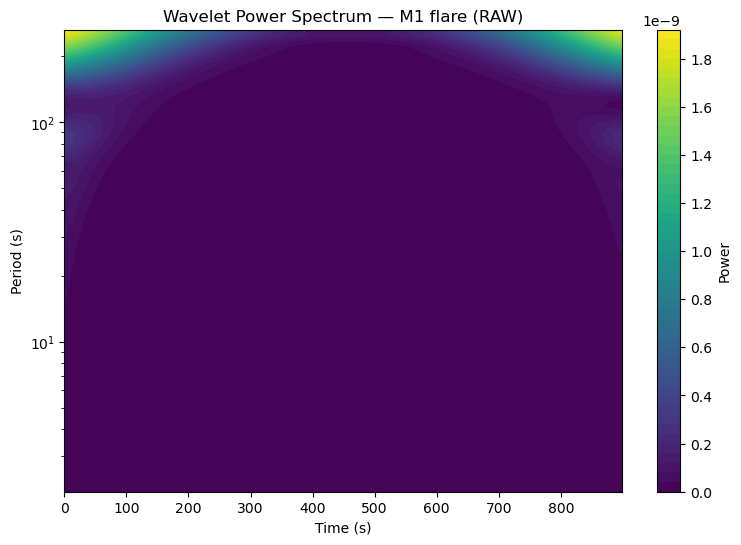

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
import pycwt as wavelet

# -----------------------------
# TIME IN SECONDS
# -----------------------------

t_M1 = (time_M1 - time_M1[0]).total_seconds()

# -----------------------------
# FOURIER TRANSFORM
# -----------------------------

dt = np.mean(np.diff(t_M1))     # sampling interval (≈1 sec)

fft_vals = fft(flux_M1)         # convert signal → frequency space
freqs = fftfreq(len(flux_M1), dt)

# keep only positive frequencies
pos = freqs > 0
freqs = freqs[pos]
power = np.abs(fft_vals[pos])**2

period = 1 / freqs

plt.figure(figsize=(7,5))
plt.plot(period, power)
plt.xscale("log")
plt.xlabel("Period (seconds)")
plt.ylabel("Power")
plt.title("Fourier Spectrum — M1 flare (RAW)")
plt.grid(alpha=0.3)
plt.show()

# -----------------------------
# WAVELET
# -----------------------------

signal = flux_M1
dt = 1

mother = wavelet.Morlet(6)
dj = 1/12
s0 = 2*dt
J = int(7/dj)

wave, scales, freqs, coi, fft, fftfreqs = wavelet.cwt(signal, dt, dj, s0, J, mother)

power = np.abs(wave)**2
period = 1 / freqs

plt.figure(figsize=(9,6))
plt.contourf(t_M1, period, power, 50)
plt.yscale("log")
plt.xlabel("Time (s)")
plt.ylabel("Period (s)")
plt.title("Wavelet Power Spectrum — M1 flare (RAW)")
plt.colorbar(label="Power")
plt.show()

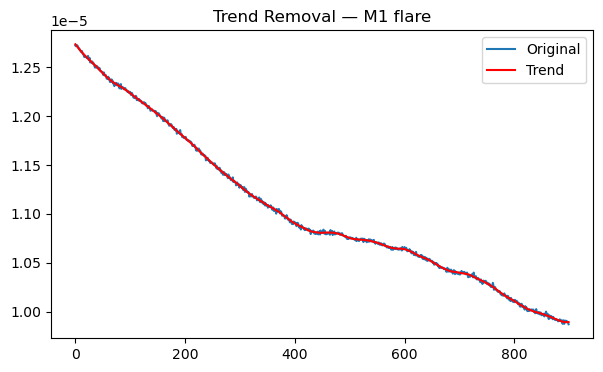

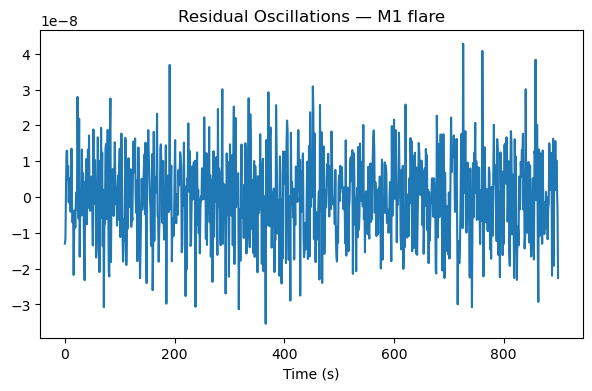

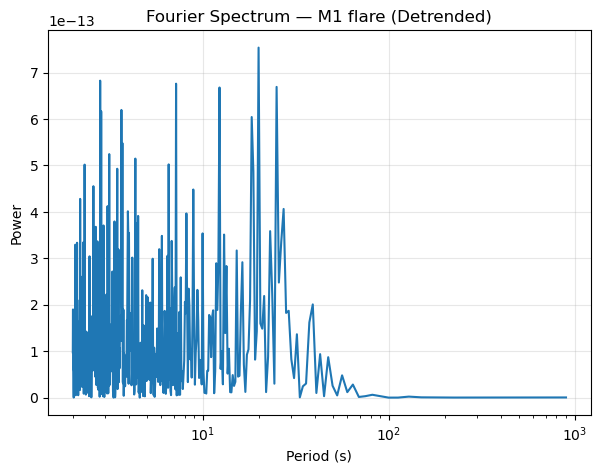

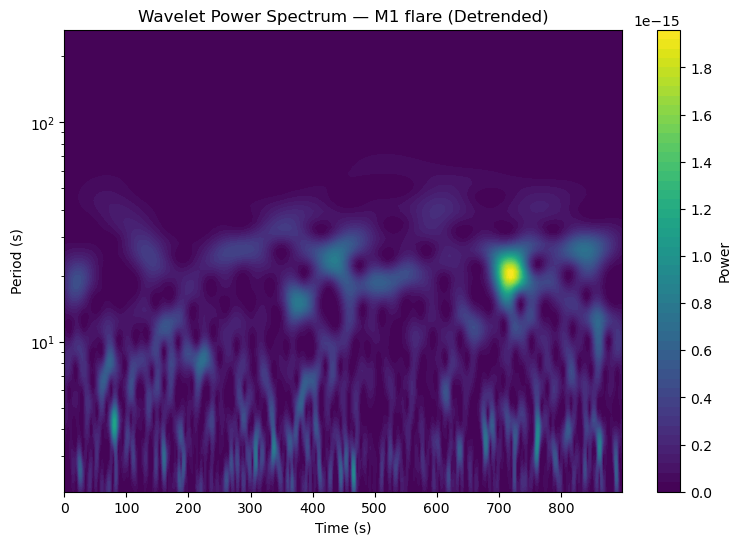

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.fft import fft, fftfreq
import pycwt as wavelet

# ---------------------------
# TIME
# ---------------------------

t_M1 = (time_M1 - time_M1[0]).total_seconds()

# ---------------------------
# TREND REMOVAL
# ---------------------------

trend = savgol_filter(flux_M1, 51, 3)
residual = flux_M1 - trend

plt.figure(figsize=(7,4))
plt.plot(t_M1, flux_M1, label="Original")
plt.plot(t_M1, trend, color="red", label="Trend")
plt.legend()
plt.title("Trend Removal — M1 flare")
plt.show()

plt.figure(figsize=(7,4))
plt.plot(t_M1, residual)
plt.title("Residual Oscillations — M1 flare")
plt.xlabel("Time (s)")
plt.show()

# ---------------------------
# FOURIER
# ---------------------------

dt = np.mean(np.diff(t_M1))

fft_vals = fft(residual)
freqs = fftfreq(len(residual), dt)

pos = freqs > 0
freqs = freqs[pos]
power = np.abs(fft_vals[pos])**2

period = 1 / freqs

plt.figure(figsize=(7,5))
plt.plot(period, power)
plt.xscale("log")
plt.xlabel("Period (s)")
plt.ylabel("Power")
plt.title("Fourier Spectrum — M1 flare (Detrended)")
plt.grid(alpha=0.3)
plt.show()

# ---------------------------
# WAVELET
# ---------------------------

signal = residual
dt = 1

mother = wavelet.Morlet(6)
dj = 1/12
s0 = 2*dt
J = int(7/dj)

wave, scales, freqs, coi, fft, fftfreqs = wavelet.cwt(signal, dt, dj, s0, J, mother)

power = np.abs(wave)**2
period = 1/freqs

plt.figure(figsize=(9,6))
plt.contourf(t_M1, period, power, 50)
plt.yscale("log")
plt.xlabel("Time (s)")
plt.ylabel("Period (s)")
plt.title("Wavelet Power Spectrum — M1 flare (Detrended)")
plt.colorbar(label="Power")
plt.show()

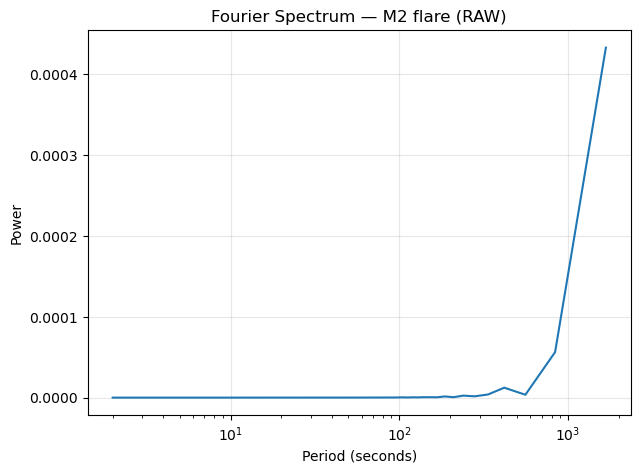

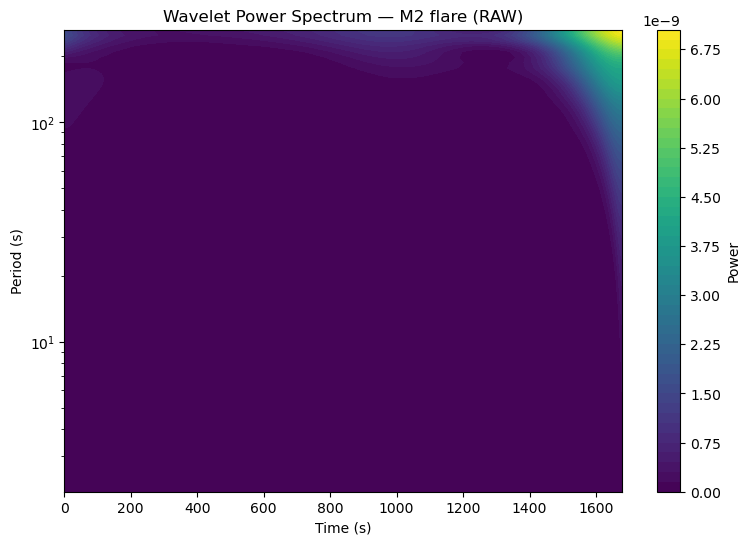

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
import pycwt as wavelet

t_M2 = (time_M2 - time_M2[0]).total_seconds()

# Fourier
dt = np.mean(np.diff(t_M2))

fft_vals = fft(flux_M2)
freqs = fftfreq(len(flux_M2), dt)

pos = freqs > 0
freqs = freqs[pos]
power = np.abs(fft_vals[pos])**2

period = 1 / freqs

plt.figure(figsize=(7,5))
plt.plot(period, power)
plt.xscale("log")
plt.xlabel("Period (seconds)")
plt.ylabel("Power")
plt.title("Fourier Spectrum — M2 flare (RAW)")
plt.grid(alpha=0.3)
plt.show()

# Wavelet
signal = flux_M2
dt = 1

mother = wavelet.Morlet(6)
dj = 1/12
s0 = 2*dt
J = int(7/dj)

wave, scales, freqs, coi, fft, fftfreqs = wavelet.cwt(signal, dt, dj, s0, J, mother)

power = np.abs(wave)**2
period = 1 / freqs

plt.figure(figsize=(9,6))
plt.contourf(t_M2, period, power, 50)
plt.yscale("log")
plt.xlabel("Time (s)")
plt.ylabel("Period (s)")
plt.title("Wavelet Power Spectrum — M2 flare (RAW)")
plt.colorbar(label="Power")
plt.show()

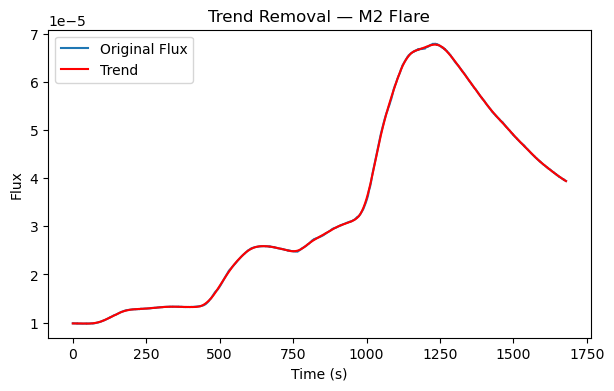

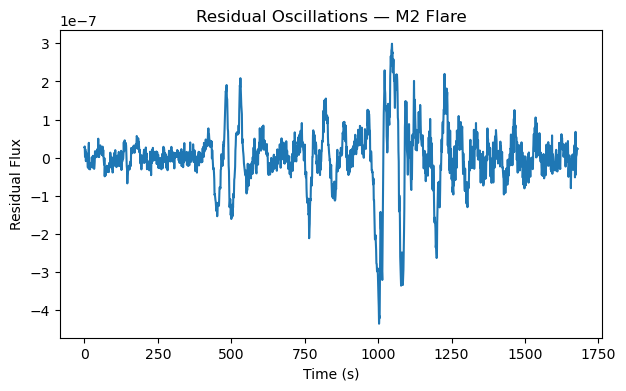

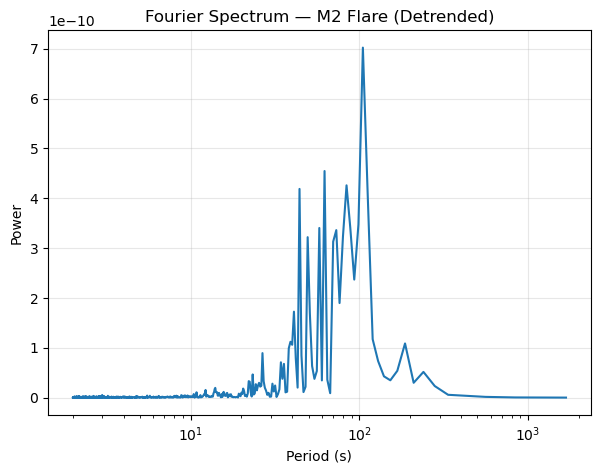

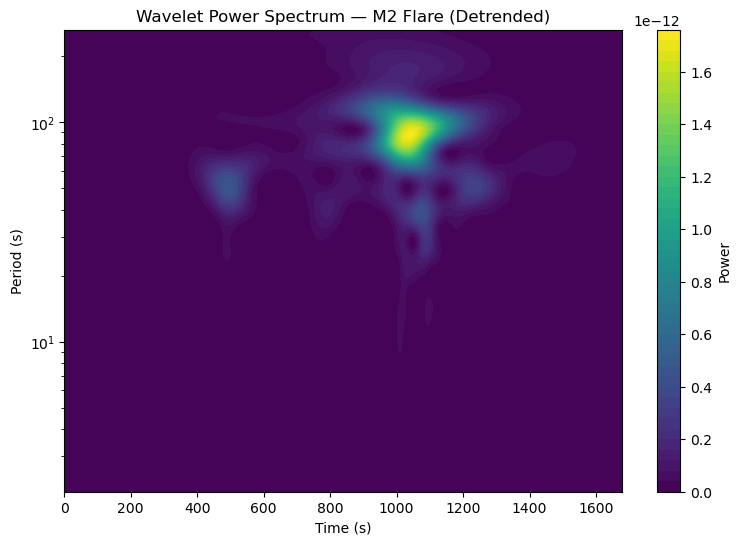

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.fft import fft, fftfreq
import pycwt as wavelet

t_M2 = (time_M2 - time_M2[0]).total_seconds()

# ----- TREND REMOVAL -----
trend = savgol_filter(flux_M2, 101, 3)
residual = flux_M2 - trend

plt.figure(figsize=(7,4))
plt.plot(t_M2, flux_M2, label="Original Flux")
plt.plot(t_M2, trend, color="red", label="Trend")
plt.legend()
plt.title("Trend Removal — M2 Flare")
plt.xlabel("Time (s)")
plt.ylabel("Flux")
plt.show()

plt.figure(figsize=(7,4))
plt.plot(t_M2, residual)
plt.title("Residual Oscillations — M2 Flare")
plt.xlabel("Time (s)")
plt.ylabel("Residual Flux")
plt.show()

# ----- FOURIER -----
dt = np.mean(np.diff(t_M2))

fft_vals = fft(residual)
freqs = fftfreq(len(residual), dt)

pos = freqs > 0
freqs = freqs[pos]
power = np.abs(fft_vals[pos])**2

period = 1 / freqs

plt.figure(figsize=(7,5))
plt.plot(period, power)
plt.xscale("log")
plt.xlabel("Period (s)")
plt.ylabel("Power")
plt.title("Fourier Spectrum — M2 Flare (Detrended)")
plt.grid(alpha=0.3)
plt.show()

# ----- WAVELET -----
signal = residual
dt = 1

mother = wavelet.Morlet(6)
dj = 1/12
s0 = 2 * dt
J = int(7 / dj)

wave, scales, freqs, coi, fft, fftfreqs = wavelet.cwt(signal, dt, dj, s0, J, mother)

power = np.abs(wave)**2
period = 1 / freqs

plt.figure(figsize=(9,6))
plt.contourf(t_M2, period, power, 50)
plt.yscale("log")
plt.xlabel("Time (s)")
plt.ylabel("Period (s)")
plt.title("Wavelet Power Spectrum — M2 Flare (Detrended)")
plt.colorbar(label="Power")
plt.show()

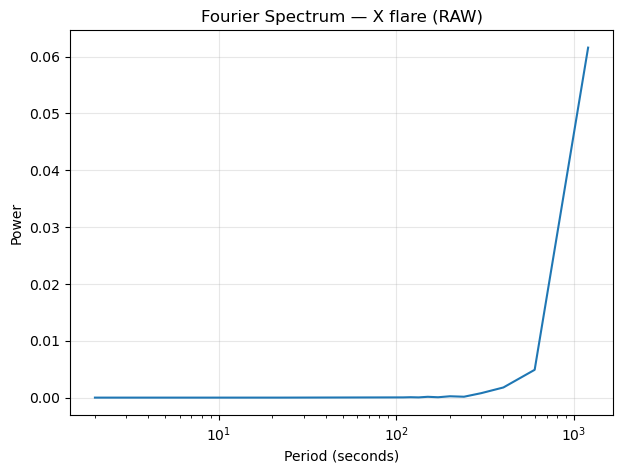

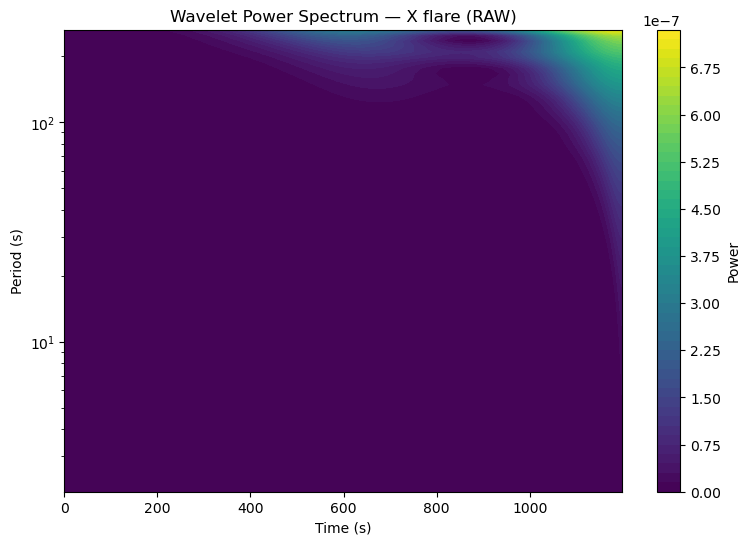

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
import pycwt as wavelet

t_X = (time_X - time_X[0]).total_seconds()

# Fourier
dt = np.mean(np.diff(t_X))

fft_vals = fft(flux_X)
freqs = fftfreq(len(flux_X), dt)

pos = freqs > 0
freqs = freqs[pos]
power = np.abs(fft_vals[pos])**2

period = 1 / freqs

plt.figure(figsize=(7,5))
plt.plot(period, power)
plt.xscale("log")
plt.xlabel("Period (seconds)")
plt.ylabel("Power")
plt.title("Fourier Spectrum — X flare (RAW)")
plt.grid(alpha=0.3)
plt.show()

# Wavelet
signal = flux_X
dt = 1

mother = wavelet.Morlet(6)
dj = 1/12
s0 = 2*dt
J = int(7/dj)

wave, scales, freqs, coi, fft, fftfreqs = wavelet.cwt(signal, dt, dj, s0, J, mother)

power = np.abs(wave)**2
period = 1 / freqs

plt.figure(figsize=(9,6))
plt.contourf(t_X, period, power, 50)
plt.yscale("log")
plt.xlabel("Time (s)")
plt.ylabel("Period (s)")
plt.title("Wavelet Power Spectrum — X flare (RAW)")
plt.colorbar(label="Power")
plt.show()

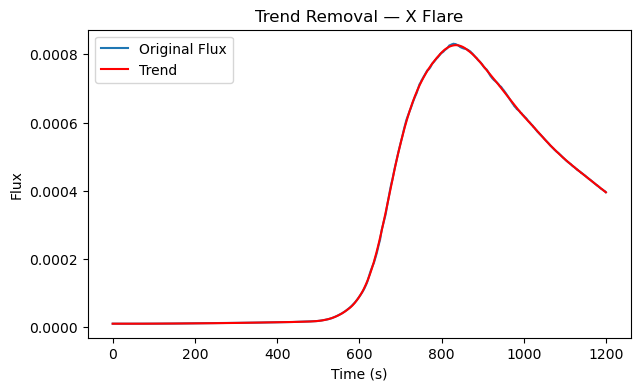

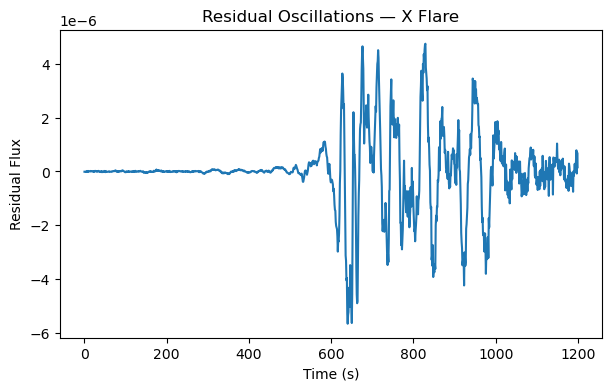

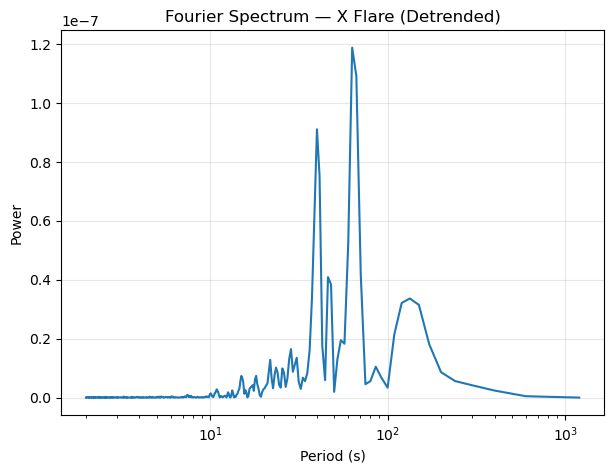

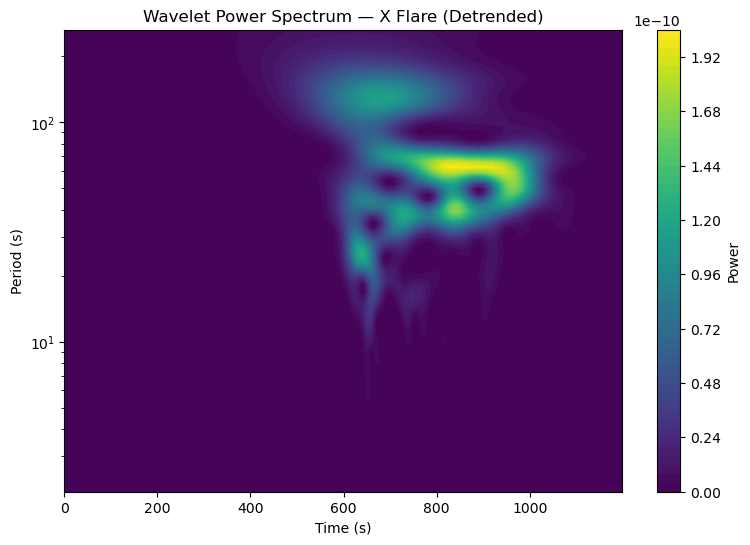

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.fft import fft, fftfreq
import pycwt as wavelet

t_X = (time_X - time_X[0]).total_seconds()

# ----- TREND REMOVAL -----
trend = savgol_filter(flux_X, 101, 3)
residual = flux_X - trend

plt.figure(figsize=(7,4))
plt.plot(t_X, flux_X, label="Original Flux")
plt.plot(t_X, trend, color="red", label="Trend")
plt.legend()
plt.title("Trend Removal — X Flare")
plt.xlabel("Time (s)")
plt.ylabel("Flux")
plt.show()

plt.figure(figsize=(7,4))
plt.plot(t_X, residual)
plt.title("Residual Oscillations — X Flare")
plt.xlabel("Time (s)")
plt.ylabel("Residual Flux")
plt.show()

# ----- FOURIER -----
dt = np.mean(np.diff(t_X))

fft_vals = fft(residual)
freqs = fftfreq(len(residual), dt)

pos = freqs > 0
freqs = freqs[pos]
power = np.abs(fft_vals[pos])**2

period = 1 / freqs

plt.figure(figsize=(7,5))
plt.plot(period, power)
plt.xscale("log")
plt.xlabel("Period (s)")
plt.ylabel("Power")
plt.title("Fourier Spectrum — X Flare (Detrended)")
plt.grid(alpha=0.3)
plt.show()

# ----- WAVELET -----
signal = residual
dt = 1

mother = wavelet.Morlet(6)
dj = 1/12
s0 = 2 * dt
J = int(7 / dj)

wave, scales, freqs, coi, fft, fftfreqs = wavelet.cwt(signal, dt, dj, s0, J, mother)

power = np.abs(wave)**2
period = 1 / freqs

plt.figure(figsize=(9,6))
plt.contourf(t_X, period, power, 50)
plt.yscale("log")
plt.xlabel("Time (s)")
plt.ylabel("Period (s)")
plt.title("Wavelet Power Spectrum — X Flare (Detrended)")
plt.colorbar(label="Power")
plt.show()

In [ ]:
"